# Lab Segmentation 2

In [1]:
from commonfunctions import *
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
def calculate_histogram(image):
    if image.dtype != np.uint8:
        image = (image * 255).astype('uint8')
    
    counts = np.zeros(256, dtype=int)
    
    for grey_level in range(256):
        counts[grey_level] = np.sum(image == grey_level)
    
    return counts

def getThreshold(image):

    # Convert to uint8
    if image.dtype != np.uint8:
        img_uint8 = np.multiply(image, 255).astype('uint8')
    else:
        img_uint8 = image
    
    # Get counts array (histogram)
    counts = calculate_histogram(img_uint8)
    
    # Get initial threshold (average grey level)
    grey_levels = np.arange(256)
    total_pixels = np.cumsum(counts)[-1]
    Tinit = round(np.sum(np.multiply(grey_levels, counts)) / total_pixels)
    
    threshold = Tinit
    prev_threshold = -1
    
    # Repeat until threshold saturates
    while threshold != prev_threshold:
        prev_threshold = threshold
        
        # Get two weighted averages
        lower_range = list(range(0, threshold))
        lower_counts = counts[lower_range]
        lower_pixels_sum = np.sum(np.multiply(lower_range, lower_counts))
        lower_total_pixels = np.sum(lower_counts)
        
        if lower_total_pixels > 0:
            mean_lower = lower_pixels_sum / lower_total_pixels
        else:
            mean_lower = 0
        
        higher_range = list(range(threshold, 256))
        higher_counts = counts[higher_range]
        higher_pixels_sum = np.sum(np.multiply(higher_range, higher_counts))
        higher_total_pixels = np.sum(higher_counts)
        
        if higher_total_pixels > 0:
            mean_higher = higher_pixels_sum / higher_total_pixels
        else:
            mean_higher = 255
        
        # Update threshold to average of two means
        threshold = round((mean_lower + mean_higher) / 2)
    
    return threshold

def experiment1(image_path):

    # Load image
    img = np.array(Image.open(image_path).convert('L'))
    
    # Get threshold
    threshold = getThreshold(img)
    
    # Apply threshold
    binary_img = np.where(img < threshold, 0, 255).astype('uint8')
    
    # Display results
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.hist(img.ravel(), bins=256, range=(0, 256), color='gray')
    plt.axvline(x=threshold, color='r', linestyle='--', label=f'Threshold = {threshold}')
    plt.title('Histogram')
    plt.legend()
    
    plt.subplot(1, 3, 3)
    plt.imshow(binary_img, cmap='gray')
    plt.title(f'Thresholded (T={threshold})')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return threshold, binary_img

def experiment2(image_path):
    """
    Experiment 2: Apply local adaptive thresholding (4 quarters)
    """
    # Load image
    img = np.array(Image.open(image_path).convert('L'))
    
    # Get global threshold for comparison
    global_threshold = getThreshold(img)
    global_binary = np.where(img < global_threshold, 0, 255).astype('uint8')
    
    # Get image dimensions
    h, w = img.shape
    mid_h = h // 2
    mid_w = w // 2
    
    # Split into 4 quarters
    quarters = [
        img[0:mid_h, 0:mid_w],      # Top-left
        img[0:mid_h, mid_w:w],       # Top-right
        img[mid_h:h, 0:mid_w],       # Bottom-left
        img[mid_h:h, mid_w:w]        # Bottom-right
    ]
    
    # Apply threshold to each quarter
    thresholded_quarters = []
    thresholds = []
    
    for i, quarter in enumerate(quarters):
        t = getThreshold(quarter)
        thresholds.append(t)
        binary_quarter = np.where(quarter < t, 0, 255).astype('uint8')
        thresholded_quarters.append(binary_quarter)
        print(f"Quarter {i+1} threshold: {t}")
    
    # Reconstruct the image
    top_half = np.hstack([thresholded_quarters[0], thresholded_quarters[1]])
    bottom_half = np.hstack([thresholded_quarters[2], thresholded_quarters[3]])
    local_binary = np.vstack([top_half, bottom_half])
    
    # Display results
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('1. Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(global_binary, cmap='gray')
    plt.title(f'2. Global Threshold (T={global_threshold})')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(local_binary, cmap='gray')
    plt.title(f'3. Local Thresholds\n(T={thresholds})')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return global_binary, local_binary, thresholds

def experiment3_improved(image_path, block_size=8):
    """
    Experiment 3 (Bonus): Improved local thresholding
    
    Justification: Instead of dividing into just 4 quarters, we divide the image
    into smaller blocks (default 8x8 grid = 64 blocks). This provides better
    adaptation to local variations in illumination and contrast, especially
    for documents with non-uniform lighting.
    """
    # Load image
    img = np.array(Image.open(image_path).convert('L'))
    h, w = img.shape
    
    # Calculate block dimensions
    block_h = h // block_size
    block_w = w // block_size
    
    # Create output image
    improved_binary = np.zeros_like(img, dtype='uint8')
    
    # Apply threshold to each block
    for i in range(block_size):
        for j in range(block_size):
            # get block
            start_h = i * block_h
            end_h = (i + 1) * block_h if i < block_size - 1 else h
            start_w = j * block_w
            end_w = (j + 1) * block_w if j < block_size - 1 else w
            
            block = img[start_h:end_h, start_w:end_w]
            
            # Get threshold for block
            if block.size > 0:
                t = getThreshold(block)
                binary_block = np.where(block < t, 0, 255).astype('uint8')
                improved_binary[start_h:end_h, start_w:end_w] = binary_block
    
    # Get global and 4-quarter results
    global_threshold = getThreshold(img)
    global_binary = np.where(img < global_threshold, 0, 255).astype('uint8')
    _, local_4quarter, _ = experiment2_no_display(img)
    
    
    plt.figure(figsize=(20, 5))
    
    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.imshow(global_binary, cmap='gray')
    plt.title(f'Global Threshold')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.imshow(local_4quarter, cmap='gray')
    plt.title('4-Quarter Local Threshold')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.imshow(improved_binary, cmap='gray')
    plt.title(f'Improved: {block_size}x{block_size} Blocks')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nJustification: The improved method divides the image into {block_size}x{block_size}={block_size**2} blocks")
    print("instead of just 4 quarters. This provides better adaptation to local variations")
    print("in illumination, which is especially important for document images with uneven lighting.")
    
    return improved_binary

def experiment2_no_display(img):
    """Helper function for experiment 2 without display (for experiment 3)"""
    h, w = img.shape
    mid_h = h // 2
    mid_w = w // 2
    
    quarters = [
        img[0:mid_h, 0:mid_w],
        img[0:mid_h, mid_w:w],
        img[mid_h:h, 0:mid_w],
        img[mid_h:h, mid_w:w]
    ]
    
    thresholded_quarters = []
    thresholds = []
    
    for quarter in quarters:
        t = getThreshold(quarter)
        thresholds.append(t)
        binary_quarter = np.where(quarter < t, 0, 255).astype('uint8')
        thresholded_quarters.append(binary_quarter)
    
    top_half = np.hstack([thresholded_quarters[0], thresholded_quarters[1]])
    bottom_half = np.hstack([thresholded_quarters[2], thresholded_quarters[3]])
    local_binary = np.vstack([top_half, bottom_half])
    
    return None, local_binary, thresholds
    

EXPERIMENT 1: Global Adaptive Thresholding

Processing cameraman.png...


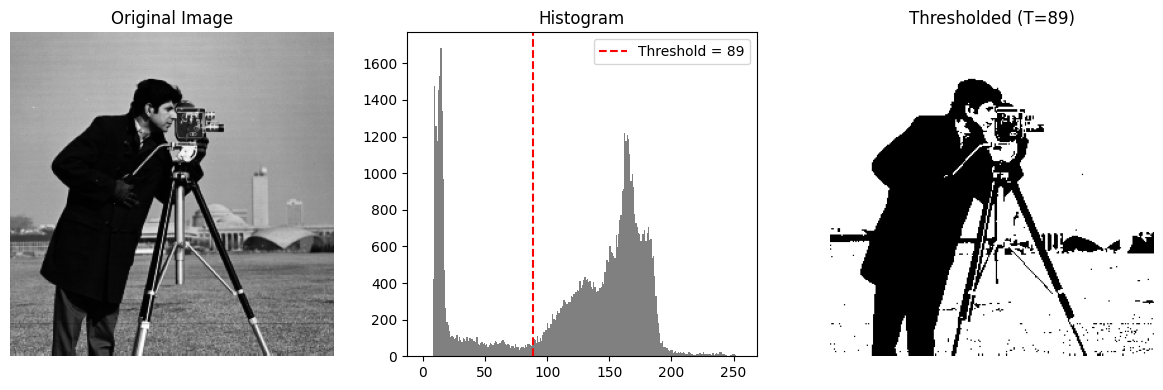

Optimal threshold for cameraman.png: 89

Processing cufe.png...


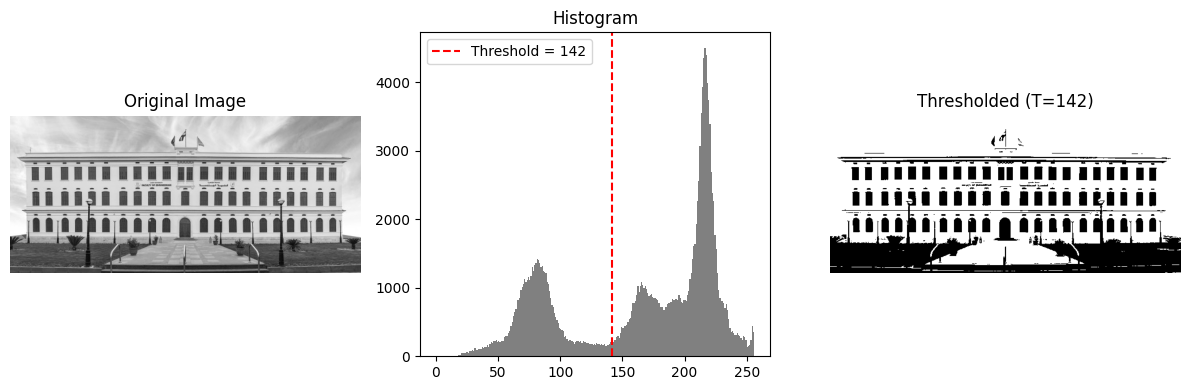

Optimal threshold for cufe.png: 142

Processing book1.png...


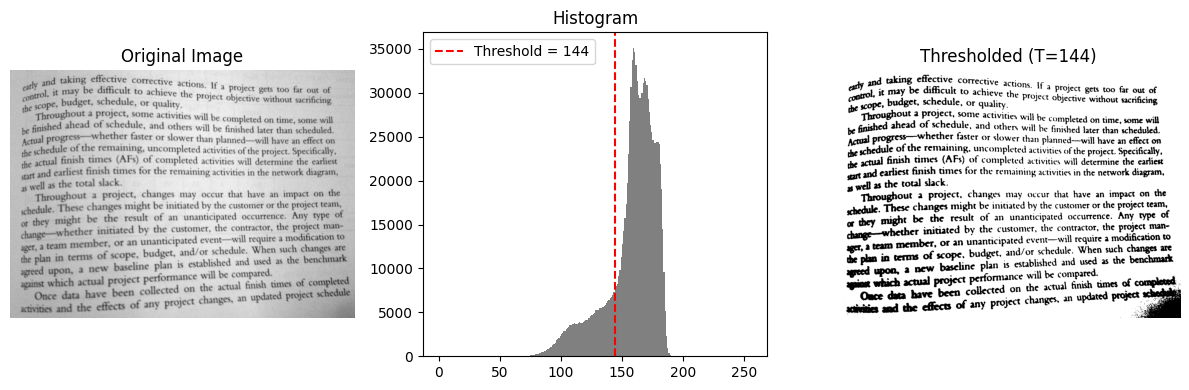

Optimal threshold for book1.png: 144

Processing book.png...


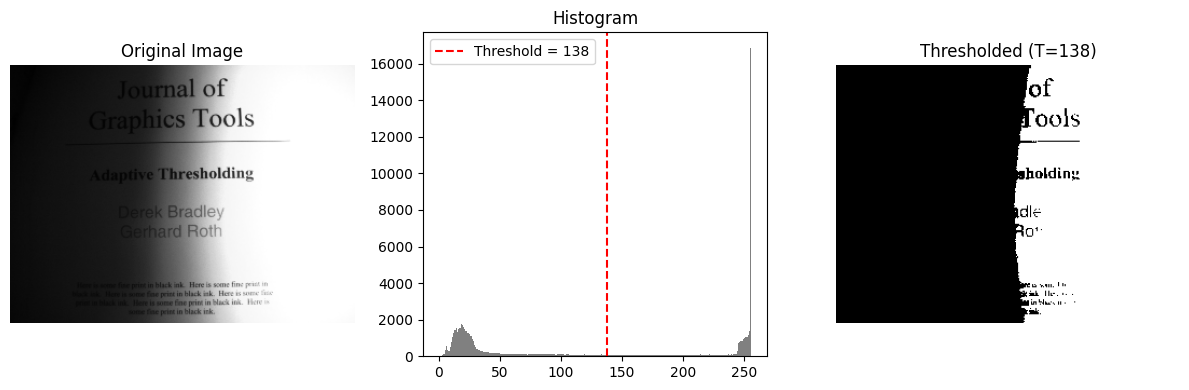

Optimal threshold for book.png: 138

EXPERIMENT 2: Local Adaptive Thresholding (4 Quarters)
Quarter 1 threshold: 46
Quarter 2 threshold: 186
Quarter 3 threshold: 50
Quarter 4 threshold: 196


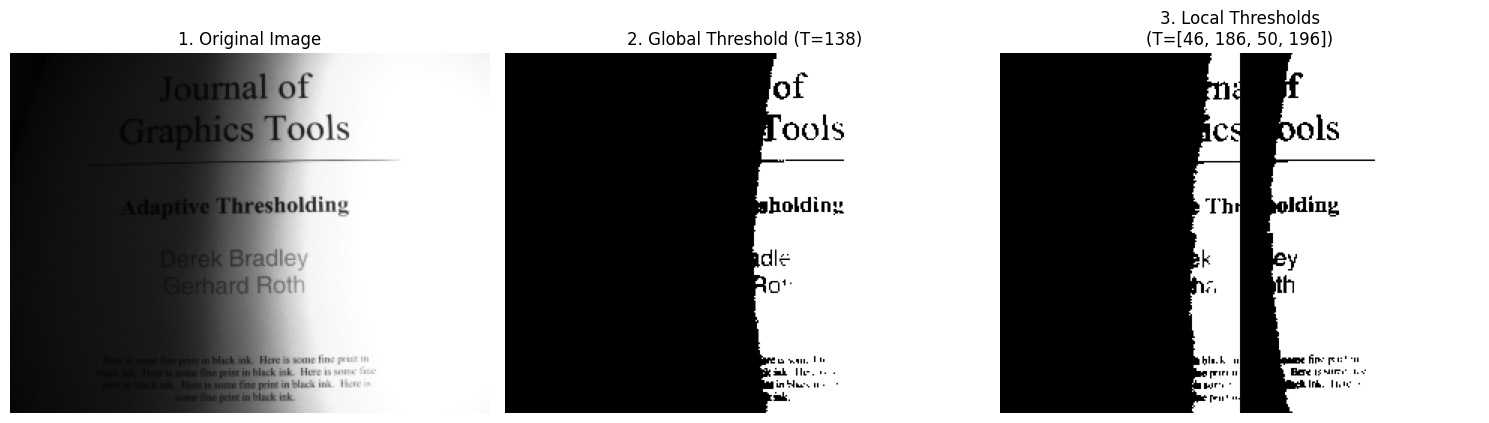


Local thresholds for each quarter: [46, 186, 50, 196]

EXPERIMENT 3 (BONUS): Improved Local Thresholding


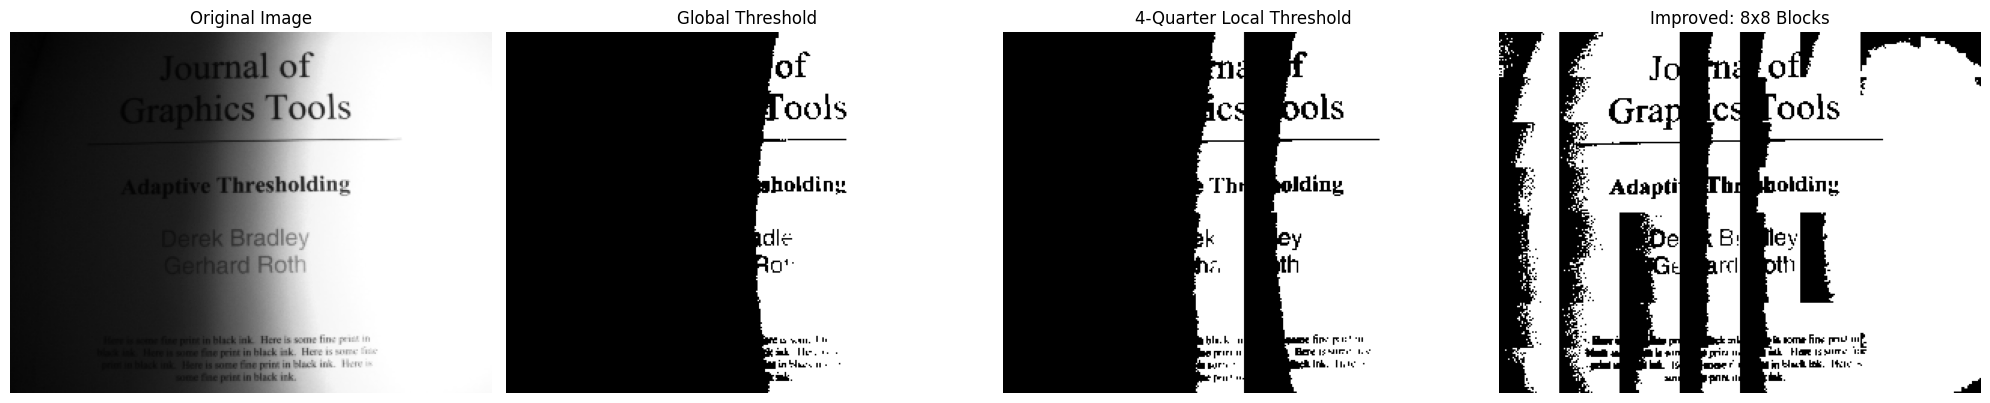


Justification: The improved method divides the image into 8x8=64 blocks
instead of just 4 quarters. This provides better adaptation to local variations
in illumination, which is especially important for document images with uneven lighting.


In [4]:

if __name__ == "__main__":
    test_images = ["cameraman.png", "cufe.png", "book1.png", "book.png"]
    
    # Experiment 1: Test on all images
    print("=" * 50)
    print("EXPERIMENT 1: Global Adaptive Thresholding")
    print("=" * 50)
    for img_name in test_images:
        try:
            print(f"\nProcessing {img_name}...")
            threshold, binary = experiment1(img_name)
            print(f"Optimal threshold for {img_name}: {threshold}")
        except FileNotFoundError:
            print(f"Image {img_name} not found. Skipping...")
    
    # Experiment 2: Local thresholding on book.png
    print("\n" + "=" * 50)
    print("EXPERIMENT 2: Local Adaptive Thresholding (4 Quarters)")
    print("=" * 50)
    try:
        global_result, local_result, thresholds = experiment2("book.png")
        print(f"\nLocal thresholds for each quarter: {thresholds}")
    except FileNotFoundError:
        print("Image book.png not found.")
    
    # Experiment 3: Improved local thresholding
    print("\n" + "=" * 50)
    print("EXPERIMENT 3 (BONUS): Improved Local Thresholding")
    print("=" * 50)
    try:
        improved = experiment3_improved("book.png", block_size=8)
    except FileNotFoundError:
        print("Image book.png not found.")
